# Sensor Capture Data Exploration

This notebook explores a CARLA sensor capture folder containing camera images and synchronized CSV outputs.

It includes:
- dataset inventory and file integrity checks
- schema and missing-value analysis
- descriptive statistics
- camera/radar alignment diagnostics
- quick visualizations

In [20]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [21]:
# Update this path if you want to explore a different capture folder.
DATASET_DIR = Path(r"C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141")
CAMERA_FRAMES_DIR = DATASET_DIR / "camera_frames"
CAMERA_CSV = DATASET_DIR / "camera_data.csv"
RADAR_CSV = DATASET_DIR / "radar_data.csv"

assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR}"
assert CAMERA_FRAMES_DIR.exists(), f"camera_frames not found: {CAMERA_FRAMES_DIR}"
assert CAMERA_CSV.exists(), f"Missing file: {CAMERA_CSV}"
assert RADAR_CSV.exists(), f"Missing file: {RADAR_CSV}"

DATASET_DIR

WindowsPath('C:/Users/Colin/Downloads/CARLA_Latest/Scripts/DatasetCreation/sensor_capture_20260325_234141')

In [22]:
def file_size_mb(path: Path) -> float:
    return path.stat().st_size / (1024 * 1024)

png_paths = sorted(CAMERA_FRAMES_DIR.rglob("*.png"))
ext_counter = Counter(p.suffix.lower() for p in CAMERA_FRAMES_DIR.rglob("*") if p.is_file())

inventory = pd.DataFrame(
    [
        {"item": "camera_frames (png count)", "value": len(png_paths)},
        {"item": "camera_data.csv size (MB)", "value": round(file_size_mb(CAMERA_CSV), 3)},
        {"item": "radar_data.csv size (MB)", "value": round(file_size_mb(RADAR_CSV), 3)},
        {
            "item": "camera_frames total size (MB)",
            "value": round(sum(p.stat().st_size for p in png_paths) / (1024 * 1024), 3),
        },
    ]
)

display(inventory)
display(pd.DataFrame([{"extension": k, "count": v} for k, v in sorted(ext_counter.items())]))

if png_paths:
    print("Sample image paths:")
    for p in png_paths[:5]:
        print(" -", p)

,item,value
0,camera_frames (png count),3527.000
1,camera_data.csv size (MB),0.628
2,radar_data.csv size (MB),30.736
3,camera_frames total size (MB),2650.141


,extension,count
0,.png,3527


Sample image paths:
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_frames\camera_24\frame_00035680.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_frames\camera_24\frame_00035681.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_frames\camera_24\frame_00035695.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_frames\camera_24\frame_00035709.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_frames\camera_24\frame_00035723.png


In [23]:
camera_df = pd.read_csv(CAMERA_CSV)
radar_df = pd.read_csv(RADAR_CSV)

print("camera_data shape:", camera_df.shape)
print("radar_data shape:", radar_df.shape)

display(camera_df.head(3))
display(radar_df.head(3))

camera_data shape: (3526, 10)
radar_data shape: (412905, 11)


,sensor_id,sensor_label,frame,timestamp,width,height,image_path,nearest_vehicle_id,nearest_vehicle_distance_m,nearby_vehicle_ids
0,24,C10,35680,230.929291,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.166045,44
1,24,C10,35681,230.941429,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.166045,44
2,24,C10,35695,231.089211,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.166045,44;45


,sensor_id,sensor_label,frame,timestamp,detection_index,depth_m,azimuth_rad,altitude_rad,velocity_mps,matched_vehicle_id,matched_vehicle_distance_m
0,27,R148,35681,230.941429,5,21.809843,-0.378402,0.022887,-0.002722,44,2.126645
1,28,R149,35683,230.962907,8,22.534670,0.693114,-0.044382,0.000000,44,4.221250
2,27,R148,35686,230.997392,3,25.777405,-0.429923,-0.038796,-0.000000,44,2.285996


In [24]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "column": df.columns,
            "missing_count": [int(df[c].isna().sum()) for c in df.columns],
        }
    )
    out["missing_pct"] = (out["missing_count"] / len(df) * 100).round(3)
    out.insert(0, "table", name)
    return out

missing_df = pd.concat(
    [missing_report(camera_df, "camera_data"), missing_report(radar_df, "radar_data")],
    ignore_index=True,
)

display(missing_df)
print("Total missing values in camera_data:", int(camera_df.isna().sum().sum()))
print("Total missing values in radar_data:", int(radar_df.isna().sum().sum()))

,table,column,missing_count,missing_pct
0,camera_data,sensor_id,0,0.0
1,camera_data,sensor_label,0,0.0
2,camera_data,frame,0,0.0
3,camera_data,timestamp,0,0.0
4,camera_data,width,0,0.0
5,camera_data,height,0,0.0
6,camera_data,image_path,0,0.0
7,camera_data,nearest_vehicle_id,0,0.0
8,camera_data,nearest_vehicle_distance_m,0,0.0
9,camera_data,nearby_vehicle_ids,0,0.0


Total missing values in camera_data: 0
Total missing values in radar_data: 0


In [25]:
# Numeric conversions
camera_num = camera_df.copy()
radar_num = radar_df.copy()

for c in ["frame", "timestamp", "width", "height", "nearest_vehicle_distance_m"]:
    if c in camera_num.columns:
        camera_num[c] = pd.to_numeric(camera_num[c], errors="coerce")

for c in [
    "frame",
    "timestamp",
    "detection_index",
    "depth_m",
    "azimuth_rad",
    "altitude_rad",
    "velocity_mps",
    "matched_vehicle_distance_m",
]:
    if c in radar_num.columns:
        radar_num[c] = pd.to_numeric(radar_num[c], errors="coerce")

camera_stats = camera_num[["frame", "timestamp", "nearest_vehicle_distance_m"]].describe().T
radar_stats = radar_num[["frame", "timestamp", "depth_m", "velocity_mps", "matched_vehicle_distance_m"]].describe().T

print("Camera numeric summary")
display(camera_stats)

print("Radar numeric summary")
display(radar_stats)

Camera numeric summary


,count,mean,std,min,25%,50%,75%,max
frame,3526.0,90137.752127,20619.535157,35680.000000,73583.750000,90293.000000,108112.250000,125335.000000
timestamp,3526.0,777.831755,219.516325,230.929291,598.254166,778.715031,967.584297,1165.845745
nearest_vehicle_distance_m,3526.0,15.490903,8.411775,0.601061,8.736423,15.849177,21.026426,34.999343


Radar numeric summary


,count,mean,std,min,25%,50%,75%,max
frame,412905.0,90402.817307,20734.490518,35681.000000,73738.000000,91111.000000,108353.000000,125362.000000
timestamp,412905.0,780.683081,221.113619,230.941429,600.171642,787.965197,970.269351,1166.189415
depth_m,412905.0,12.351318,6.863532,3.384805,6.163655,10.395418,16.938837,40.237667
velocity_mps,412905.0,1.744828,2.387271,-3.620722,0.000000,0.414285,3.823411,8.794242
matched_vehicle_distance_m,412905.0,3.043116,1.476649,0.032906,1.791990,2.584979,4.358428,5.999986


In [26]:
# Frame-level alignment checks
camera_frames = set(camera_num["frame"].dropna().astype(int).tolist())
radar_frames = set(radar_num["frame"].dropna().astype(int).tolist())

common_frames = camera_frames & radar_frames
camera_only_frames = camera_frames - radar_frames
radar_only_frames = radar_frames - camera_frames

png_frame_ids = set()
for p in png_paths:
    stem = p.stem  # e.g. frame_00259918
    if stem.startswith("frame_"):
        try:
            png_frame_ids.add(int(stem.split("_")[1]))
        except ValueError:
            pass

csv_without_png = sorted(list(camera_frames - png_frame_ids))
png_without_csv = sorted(list(png_frame_ids - camera_frames))

alignment_summary = pd.DataFrame(
    [
        {"metric": "camera unique frames", "value": len(camera_frames)},
        {"metric": "radar unique frames", "value": len(radar_frames)},
        {"metric": "common frames", "value": len(common_frames)},
        {"metric": "camera-only frames", "value": len(camera_only_frames)},
        {"metric": "radar-only frames", "value": len(radar_only_frames)},
        {"metric": "camera CSV frames without PNG", "value": len(csv_without_png)},
        {"metric": "PNG frames without camera CSV row", "value": len(png_without_csv)},
    ]
)

display(alignment_summary)
print("Sample camera CSV frames without PNG:", csv_without_png[:10])
print("Sample PNG frames without camera CSV row:", png_without_csv[:10])

,metric,value
0,camera unique frames,3526
1,radar unique frames,50786
2,common frames,3484
3,camera-only frames,42
4,radar-only frames,47302
5,camera CSV frames without PNG,0
6,PNG frames without camera CSV row,1


Sample camera CSV frames without PNG: []
Sample PNG frames without camera CSV row: [125346]


,sensors_in_frame,frame_count
0,1,7468
1,2,18816
2,3,13366
3,4,11136


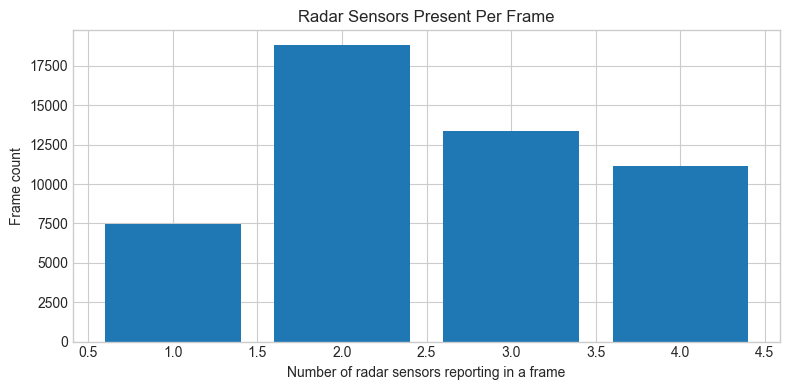

In [27]:
# Radar sensor participation per frame
radar_sensor_frame = radar_df.groupby("frame")["sensor_id"].nunique().rename("radar_sensor_count").reset_index()
sensor_count_dist = (
    radar_sensor_frame["radar_sensor_count"]
    .value_counts()
    .sort_index()
    .rename_axis("sensors_in_frame")
    .reset_index(name="frame_count")
)

display(sensor_count_dist)

plt.figure(figsize=(8, 4))
plt.bar(sensor_count_dist["sensors_in_frame"], sensor_count_dist["frame_count"])
plt.title("Radar Sensors Present Per Frame")
plt.xlabel("Number of radar sensors reporting in a frame")
plt.ylabel("Frame count")
plt.tight_layout()
plt.show()

Camera timestamp delta summary (seconds):
{
  "min": 0.008775000000014188,
  "median": 0.1351119999999355,
  "mean": 0.26522452595744683,
  "max": 201.85102300000003
}

Radar unique timestamp delta summary (seconds):
{
  "min": 0.00720700000002239,
  "median": 0.010515999999995529,
  "mean": 0.018415831170621247,
  "max": 196.511871
}


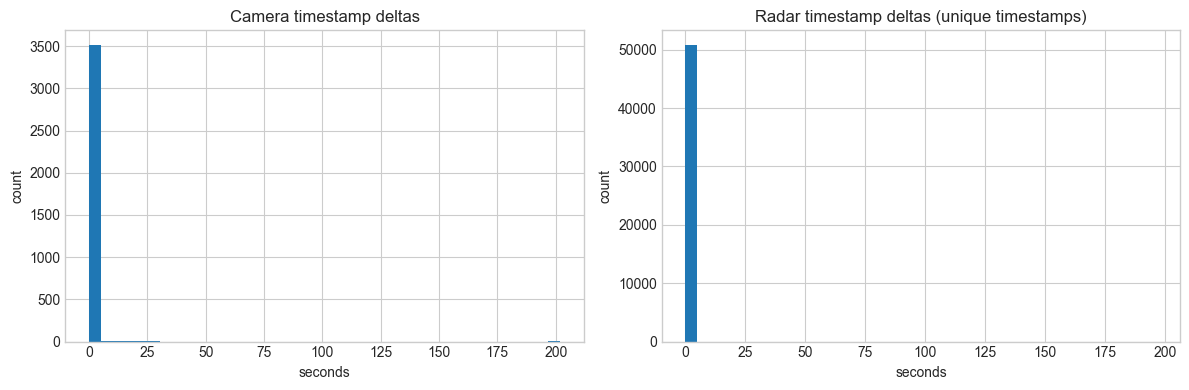

In [28]:
# Timestamp gap analysis
camera_ts = np.sort(camera_num["timestamp"].dropna().to_numpy())
radar_ts = np.sort(radar_num["timestamp"].dropna().unique())

camera_dt = np.diff(camera_ts) if len(camera_ts) > 1 else np.array([])
radar_dt = np.diff(radar_ts) if len(radar_ts) > 1 else np.array([])

def gap_summary(arr: np.ndarray) -> dict:
    if arr.size == 0:
        return {"min": None, "median": None, "mean": None, "max": None}
    return {
        "min": float(np.min(arr)),
        "median": float(np.median(arr)),
        "mean": float(np.mean(arr)),
        "max": float(np.max(arr)),
    }

print("Camera timestamp delta summary (seconds):")
print(json.dumps(gap_summary(camera_dt), indent=2))
print("\nRadar unique timestamp delta summary (seconds):")
print(json.dumps(gap_summary(radar_dt), indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(camera_dt, bins=40)
axes[0].set_title("Camera timestamp deltas")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("count")

axes[1].hist(radar_dt, bins=40)
axes[1].set_title("Radar timestamp deltas (unique timestamps)")
axes[1].set_xlabel("seconds")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

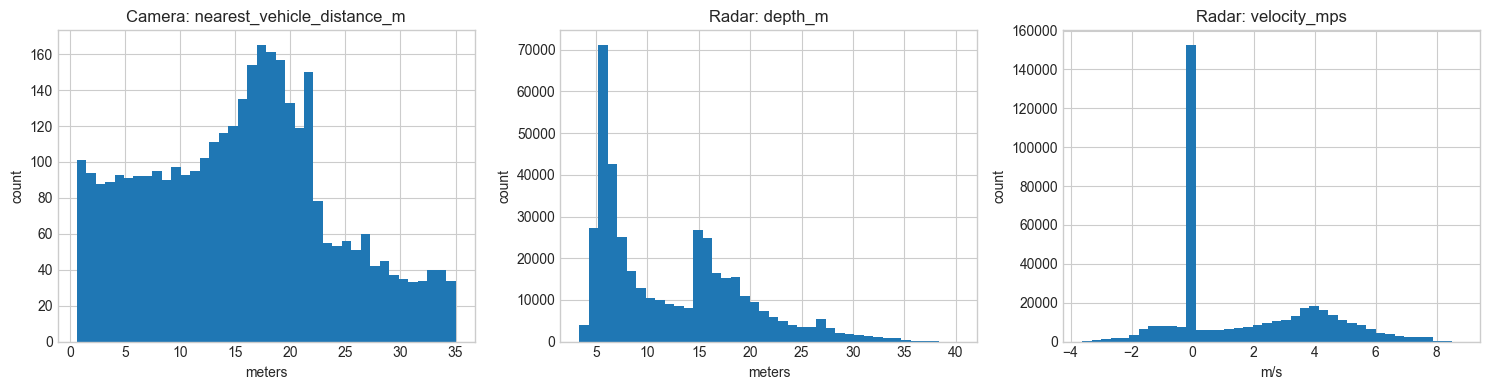

In [29]:
# Distribution plots for key measurements
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(camera_num["nearest_vehicle_distance_m"].dropna(), bins=40)
axes[0].set_title("Camera: nearest_vehicle_distance_m")
axes[0].set_xlabel("meters")

axes[1].hist(radar_num["depth_m"].dropna(), bins=40)
axes[1].set_title("Radar: depth_m")
axes[1].set_xlabel("meters")

axes[2].hist(radar_num["velocity_mps"].dropna(), bins=40)
axes[2].set_title("Radar: velocity_mps")
axes[2].set_xlabel("m/s")

for ax in axes:
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [30]:
# Optional: save a compact exploration report as JSON.
report = {
    "dataset_dir": str(DATASET_DIR),
    "camera_rows": int(len(camera_df)),
    "radar_rows": int(len(radar_df)),
    "camera_unique_frames": int(len(camera_frames)),
    "radar_unique_frames": int(len(radar_frames)),
    "common_frames": int(len(common_frames)),
    "camera_only_frames": int(len(camera_only_frames)),
    "radar_only_frames": int(len(radar_only_frames)),
    "camera_csv_without_png": int(len(csv_without_png)),
    "png_without_camera_csv": int(len(png_without_csv)),
    "camera_timestamp_delta_sec": gap_summary(camera_dt),
    "radar_unique_timestamp_delta_sec": gap_summary(radar_dt),
}

report_path = DATASET_DIR / "exploration_report.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")
print("Saved:", report_path)

Saved: C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\exploration_report.json


In [31]:
# Build a camera-radar paired dataset using nearest timestamp matching.
# You can tune tolerance based on your desired synchronization strictness.

TOLERANCE_MS = 30  # try 20, 30, or 50
TOLERANCE_SEC = TOLERANCE_MS / 1000.0

# Aggregate radar detections to one row per radar frame/timestamp.
radar_frame_level = (
    radar_num
    .groupby(["frame", "timestamp"], as_index=False)
    .agg(
        radar_detection_count=("detection_index", "count"),
        radar_depth_m_mean=("depth_m", "mean"),
        radar_depth_m_min=("depth_m", "min"),
        radar_depth_m_max=("depth_m", "max"),
        radar_velocity_mps_mean=("velocity_mps", "mean"),
        radar_velocity_mps_min=("velocity_mps", "min"),
        radar_velocity_mps_max=("velocity_mps", "max"),
        radar_matched_vehicle_dist_m_mean=("matched_vehicle_distance_m", "mean"),
        radar_unique_sensor_count=("sensor_id", "nunique"),
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

camera_sorted = camera_num.sort_values("timestamp").reset_index(drop=True).copy()

paired = pd.merge_asof(
    camera_sorted,
    radar_frame_level,
    on="timestamp",
    direction="nearest",
    tolerance=TOLERANCE_SEC,
    suffixes=("_camera", "_radar"),
)

# Keep the original camera timestamp and compute exact join error.
paired = paired.rename(columns={"timestamp": "camera_timestamp"})

# Recover radar timestamp via second merge for transparent error accounting.
radar_ts_lookup = radar_frame_level[["frame", "timestamp"]].rename(
    columns={"frame": "frame_radar", "timestamp": "radar_timestamp"}
)
paired = paired.merge(radar_ts_lookup, on="frame_radar", how="left")

# Rerun-safe handling in case a prior run left radar_timestamp columns around.
if "radar_timestamp_y" in paired.columns:
    paired["radar_timestamp"] = paired["radar_timestamp_y"]
    drop_cols = [c for c in ["radar_timestamp_x", "radar_timestamp_y"] if c in paired.columns]
    paired = paired.drop(columns=drop_cols)
elif "radar_timestamp" not in paired.columns and "radar_timestamp_x" in paired.columns:
    paired = paired.rename(columns={"radar_timestamp_x": "radar_timestamp"})

paired["abs_time_delta_ms"] = (paired["camera_timestamp"] - paired["radar_timestamp"]).abs() * 1000.0

matched = paired[paired["frame_radar"].notna()].copy()
unmatched = paired[paired["frame_radar"].isna()].copy()

match_rate = (len(matched) / len(paired) * 100.0) if len(paired) else 0.0

print(f"Tolerance: {TOLERANCE_MS} ms")
print(f"Camera rows: {len(paired)}")
print(f"Matched rows: {len(matched)} ({match_rate:.2f}%)")
print(f"Unmatched rows: {len(unmatched)}")

if len(matched):
    print("Matched abs_time_delta_ms summary:")
    print(matched["abs_time_delta_ms"].describe(percentiles=[0.25, 0.5, 0.75]).round(3))

match_report = pd.DataFrame(
    [
        {"metric": "tolerance_ms", "value": TOLERANCE_MS},
        {"metric": "camera_rows", "value": len(paired)},
        {"metric": "matched_rows", "value": len(matched)},
        {"metric": "unmatched_rows", "value": len(unmatched)},
        {"metric": "match_rate_pct", "value": round(match_rate, 3)},
        {
            "metric": "matched_median_abs_time_delta_ms",
            "value": round(float(matched["abs_time_delta_ms"].median()), 3) if len(matched) else np.nan,
        },
    ]
)

display(match_report)
display(matched.head(5))

paired_csv = DATASET_DIR / f"camera_radar_paired_{TOLERANCE_MS}ms.csv"
matched_csv = DATASET_DIR / f"camera_radar_paired_matched_{TOLERANCE_MS}ms.csv"

paired.to_csv(paired_csv, index=False)
matched.to_csv(matched_csv, index=False)

print("Saved:")
print(" -", paired_csv)
print(" -", matched_csv)

Tolerance: 30 ms
Camera rows: 3526
Matched rows: 3526 (100.00%)
Unmatched rows: 0
Matched abs_time_delta_ms summary:
count    3526.000
mean        0.122
std         1.136
min         0.000
25%         0.000
50%         0.000
75%         0.000
max        21.787
Name: abs_time_delta_ms, dtype: float64


,metric,value
0,tolerance_ms,30.0
1,camera_rows,3526.0
2,matched_rows,3526.0
3,unmatched_rows,0.0
4,match_rate_pct,100.0
5,matched_median_abs_time_delta_ms,0.0


,sensor_id,sensor_label,frame_camera,camera_timestamp,width,height,image_path,nearest_vehicle_id,nearest_vehicle_distance_m,nearby_vehicle_ids,...,radar_depth_m_mean,radar_depth_m_min,radar_depth_m_max,radar_velocity_mps_mean,radar_velocity_mps_min,radar_velocity_mps_max,radar_matched_vehicle_dist_m_mean,radar_unique_sensor_count,radar_timestamp,abs_time_delta_ms
0,24,C10,35680,230.929291,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.166045,44,...,21.809843,21.809843,21.809843,-0.002722,-0.002722,-0.002722,2.126645,1,230.941429,12.138
1,24,C10,35681,230.941429,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.166045,44,...,21.809843,21.809843,21.809843,-0.002722,-0.002722,-0.002722,2.126645,1,230.941429,0.000
2,24,C10,35695,231.089211,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.166045,44;45,...,19.577352,17.774157,21.380548,0.000000,0.000000,0.000000,4.104713,1,231.089211,0.000
3,24,C10,35709,231.257121,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.165856,44;45,...,25.456862,23.350821,27.562904,-0.055002,-0.110004,-0.000000,3.527358,1,231.245990,11.131
4,24,C10,35723,231.409442,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,44,27.161115,44;45,...,19.671321,16.899858,23.980080,-0.003431,-0.010292,-0.000000,3.934595,2,231.409442,0.000


Saved:
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_radar_paired_30ms.csv
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_234141\camera_radar_paired_matched_30ms.csv


C:\Users\Colin\AppData\Local\Temp\ipykernel_8556\2026800231.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


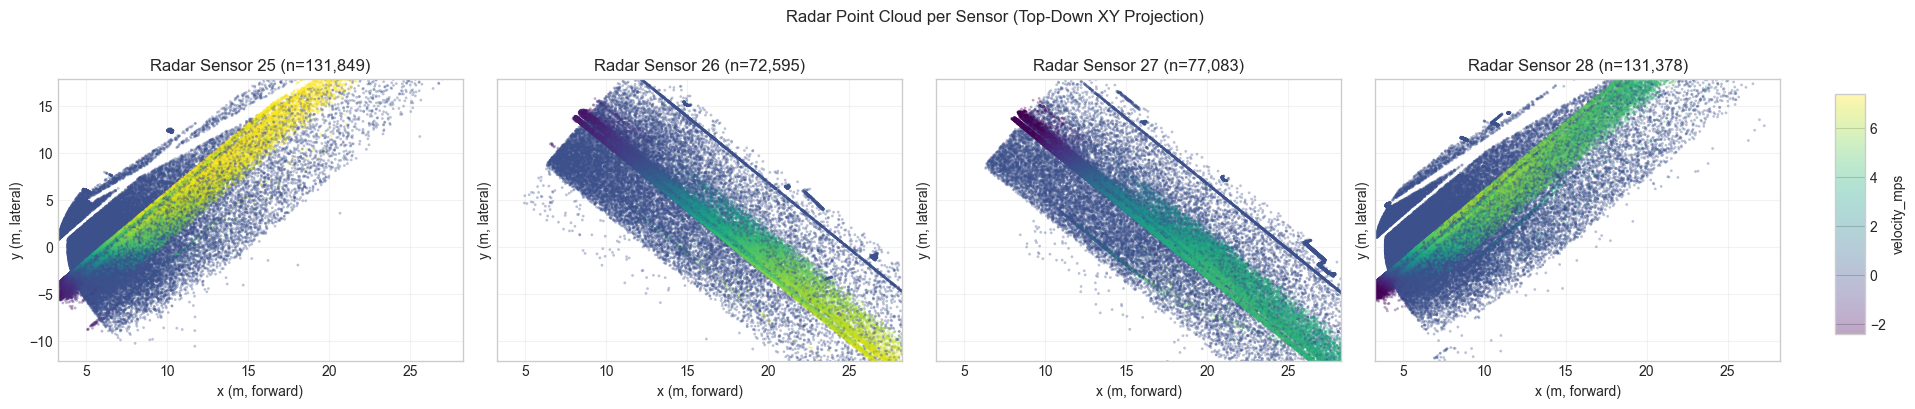

In [32]:
# Radar cloud per sensor (top-down projection)
# Uses all detections and plots one subplot per radar sensor.

# Ensure numeric types (safe if already converted earlier).
radar_plot = radar_num.copy()
for c in ["sensor_id", "depth_m", "azimuth_rad", "velocity_mps"]:
    radar_plot[c] = pd.to_numeric(radar_plot[c], errors="coerce")
radar_plot = radar_plot.dropna(subset=["sensor_id", "depth_m", "azimuth_rad", "velocity_mps"]).copy()
radar_plot["sensor_id"] = radar_plot["sensor_id"].astype(int)

# Convert polar radar measurements to XY in sensor-local top-down plane.
# x: forward distance, y: lateral distance.
radar_plot["x_m"] = radar_plot["depth_m"] * np.cos(radar_plot["azimuth_rad"])
radar_plot["y_m"] = radar_plot["depth_m"] * np.sin(radar_plot["azimuth_rad"])

sensor_ids = sorted(radar_plot["sensor_id"].unique())
if len(sensor_ids) == 0:
    raise ValueError("No radar detections available to plot.")

n = len(sensor_ids)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

# Global limits for comparable panels.
x_min, x_max = radar_plot["x_m"].quantile([0.01, 0.99])
y_min, y_max = radar_plot["y_m"].quantile([0.01, 0.99])

vmin, vmax = radar_plot["velocity_mps"].quantile([0.01, 0.99])

for i, sid in enumerate(sensor_ids):
    ax = axes[i]
    df_s = radar_plot[radar_plot["sensor_id"] == sid]

    sc = ax.scatter(
        df_s["x_m"],
        df_s["y_m"],
        c=df_s["velocity_mps"],
        s=4,
        alpha=0.35,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
    )
    ax.set_title(f"Radar Sensor {sid} (n={len(df_s):,})")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x (m, forward)")
    ax.set_ylabel("y (m, lateral)")
    ax.grid(True, alpha=0.25)

# Hide unused axes.
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Reserve right margin and place colorbar outside subplot grid.
fig.subplots_adjust(right=0.90)
cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("velocity_mps")

fig.suptitle("Radar Point Cloud per Sensor (Top-Down XY Projection)", y=1.01)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

Plotting 10 frame(s): [np.int64(35681), np.int64(35683), np.int64(35686), np.int64(35687), np.int64(35689), np.int64(35692), np.int64(35693), np.int64(35694), np.int64(35695), np.int64(35696)]


C:\Users\Colin\AppData\Local\Temp\ipykernel_8556\3590111079.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


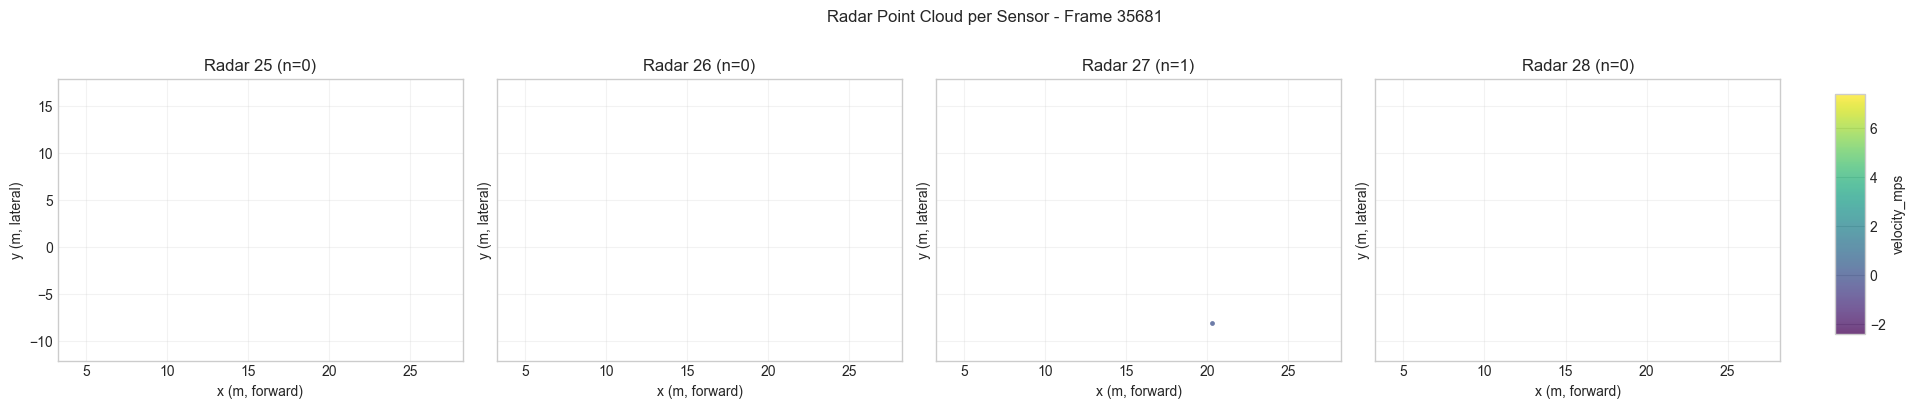

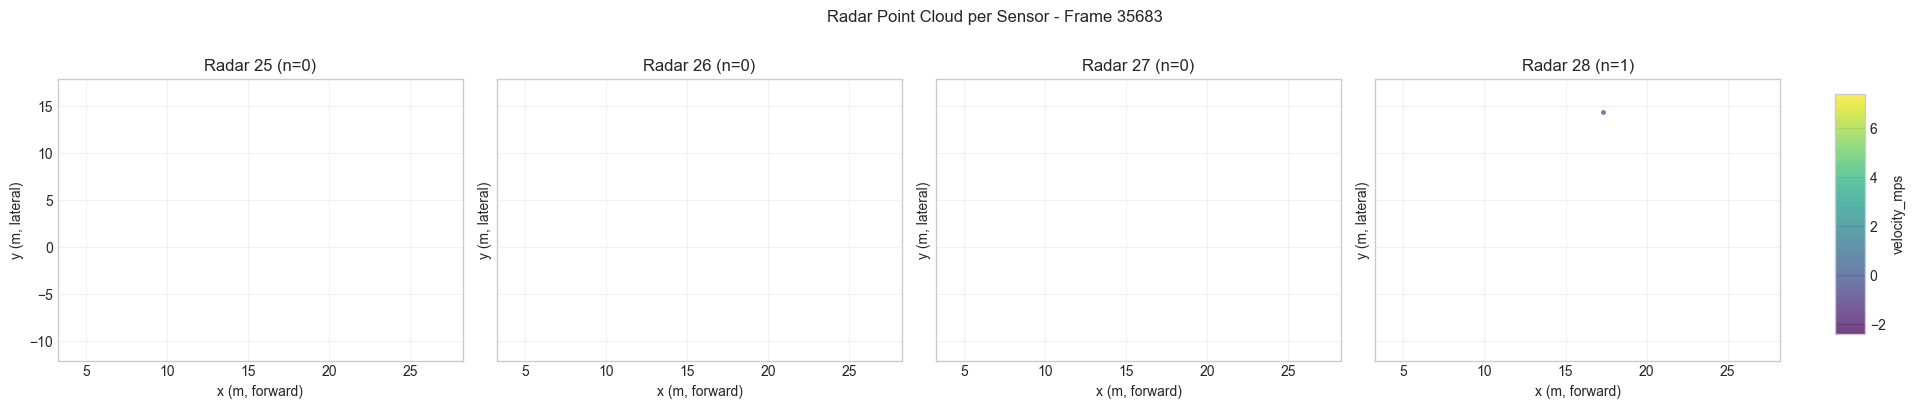

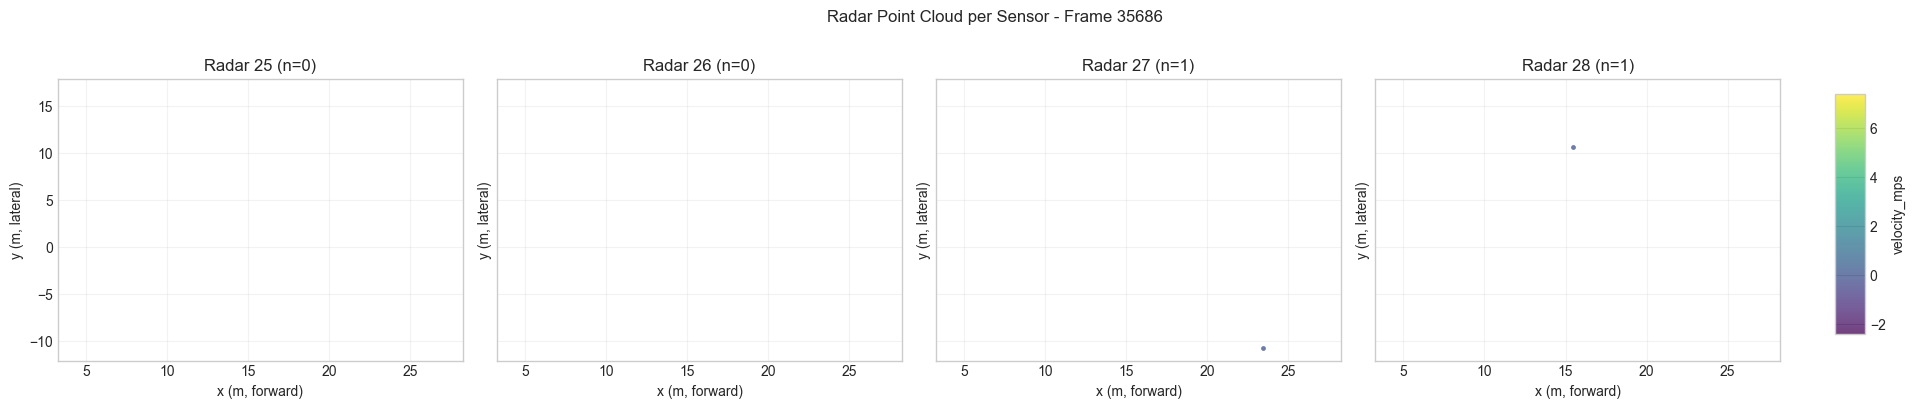

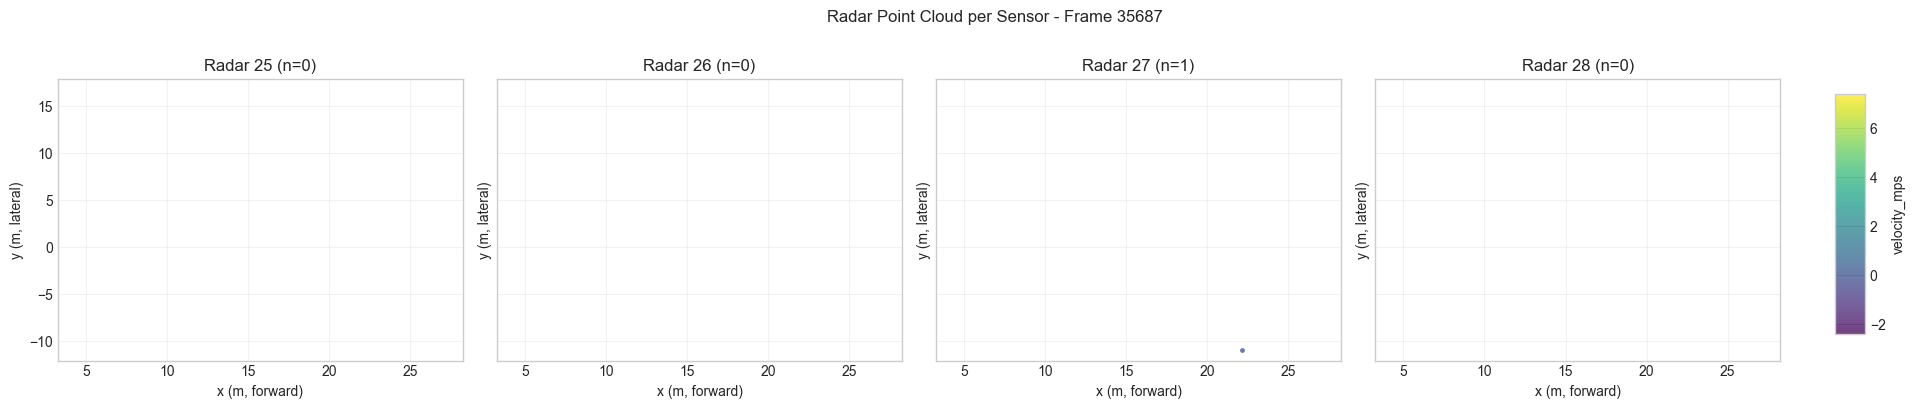

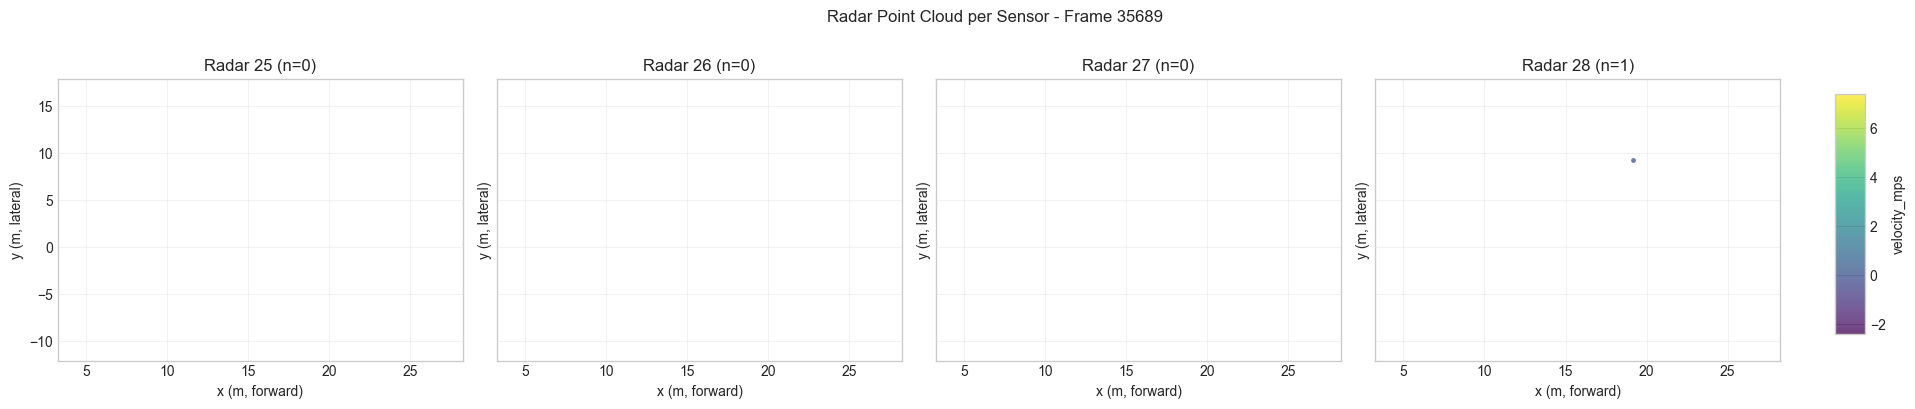

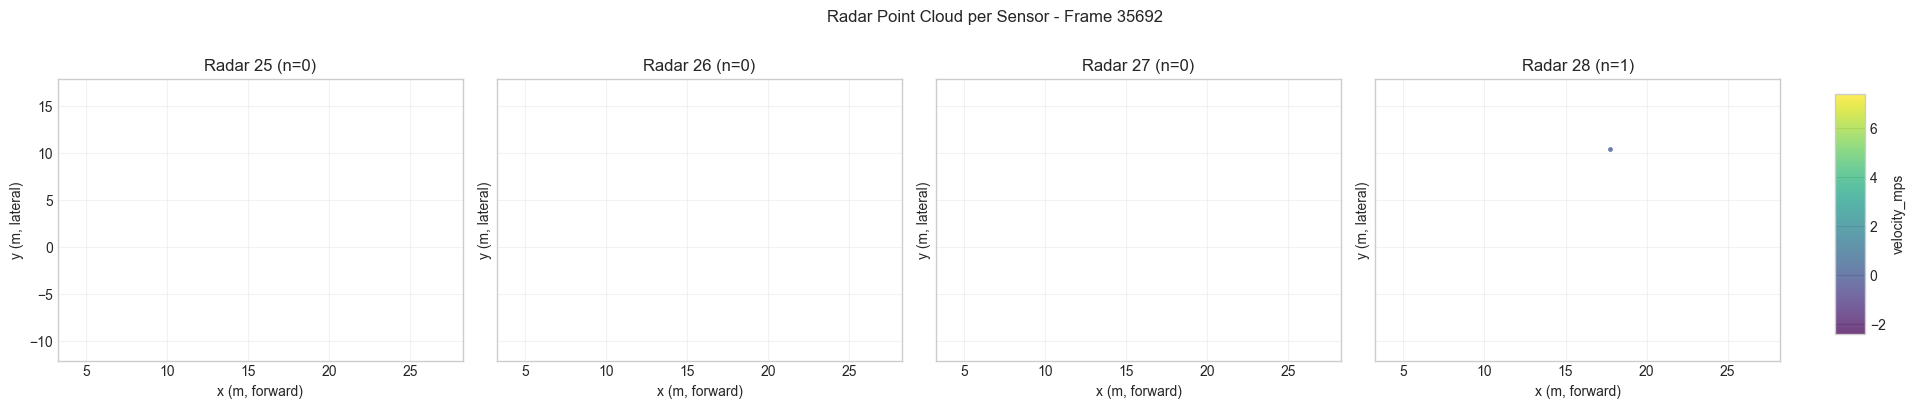

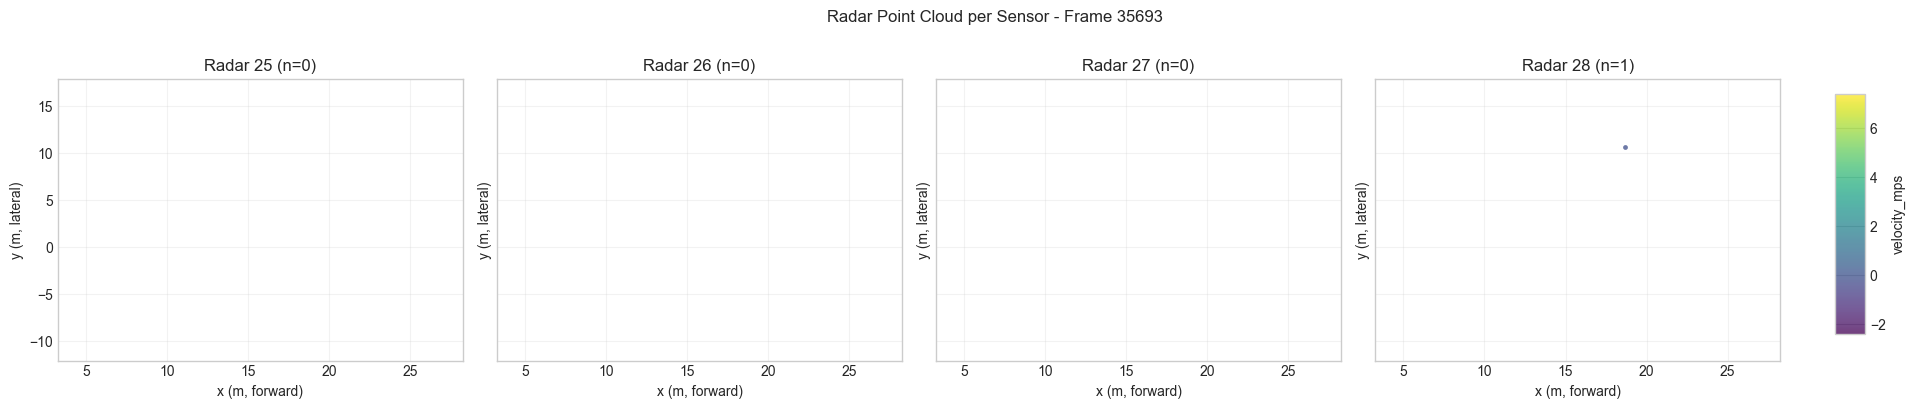

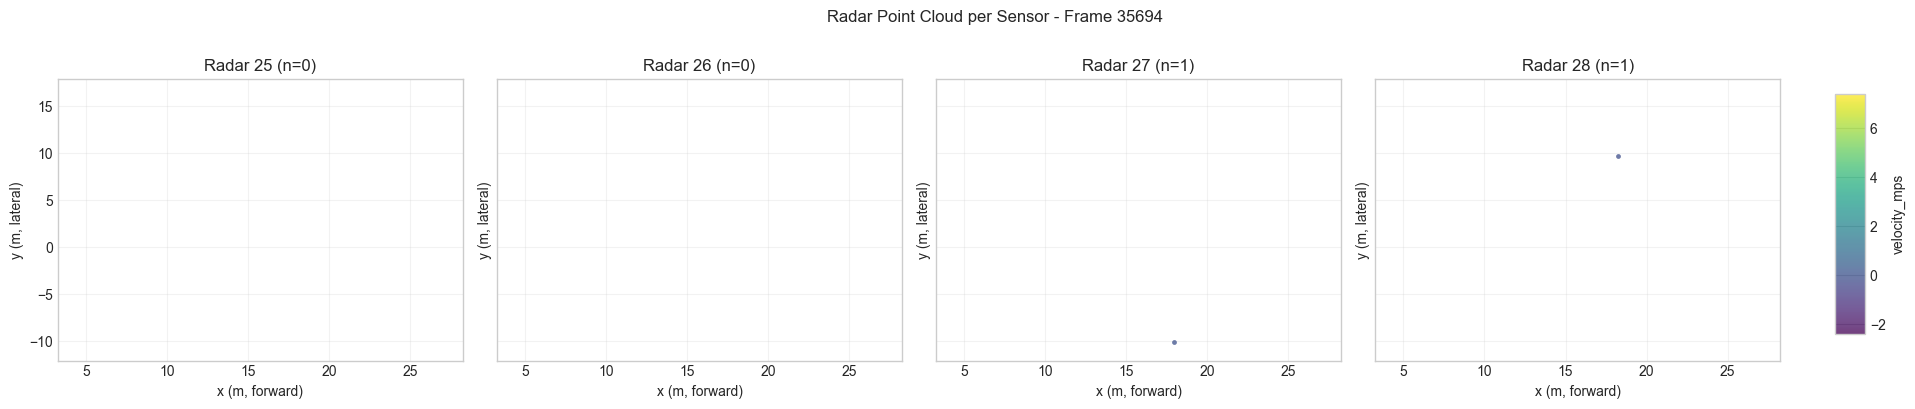

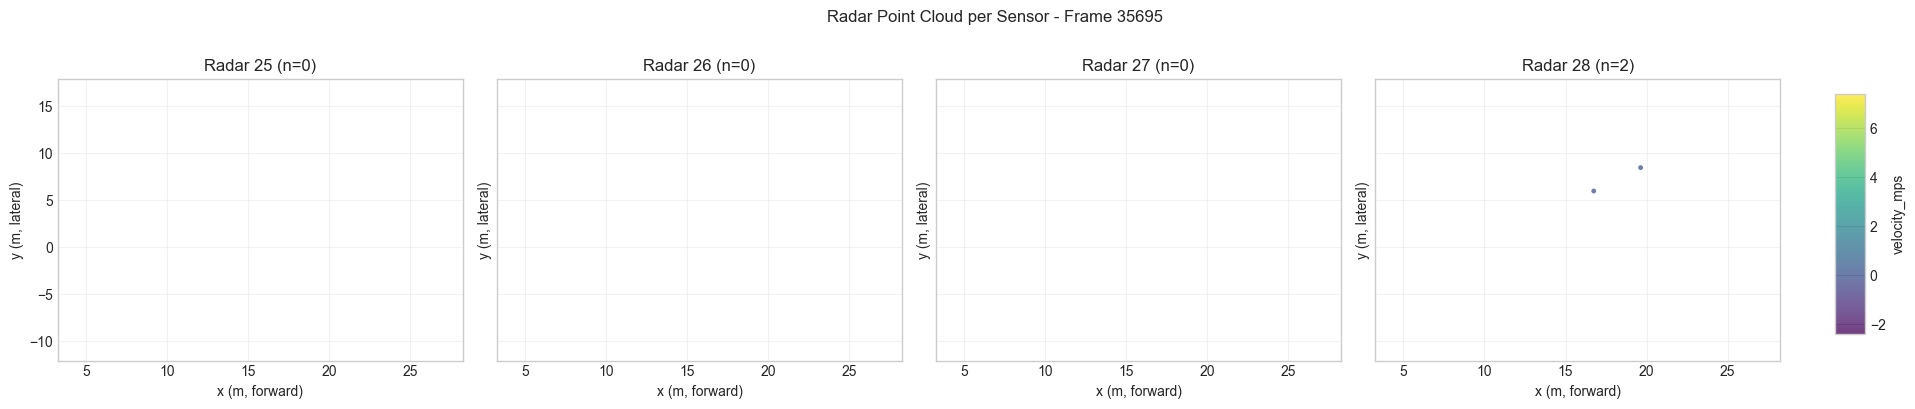

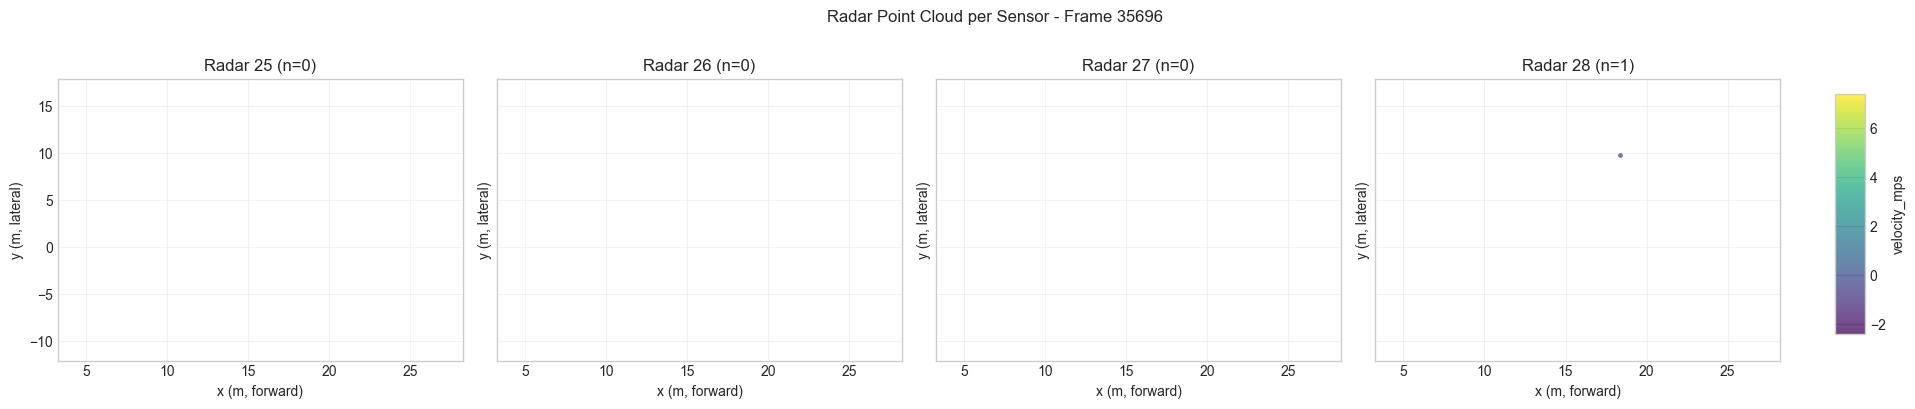

In [33]:
# Radar cloud per sensor, frame-by-frame (first N frames)
# This shows temporal snapshots instead of aggregating all frames.

MAX_FRAMES = 10

radar_frame_plot = radar_num.copy()
for c in ["sensor_id", "frame", "depth_m", "azimuth_rad", "velocity_mps"]:
    radar_frame_plot[c] = pd.to_numeric(radar_frame_plot[c], errors="coerce")

radar_frame_plot = radar_frame_plot.dropna(
    subset=["sensor_id", "frame", "depth_m", "azimuth_rad", "velocity_mps"]
).copy()
radar_frame_plot["sensor_id"] = radar_frame_plot["sensor_id"].astype(int)
radar_frame_plot["frame"] = radar_frame_plot["frame"].astype(int)

# Convert polar measurements to top-down XY in sensor-local coordinates.
radar_frame_plot["x_m"] = radar_frame_plot["depth_m"] * np.cos(radar_frame_plot["azimuth_rad"])
radar_frame_plot["y_m"] = radar_frame_plot["depth_m"] * np.sin(radar_frame_plot["azimuth_rad"])

sensor_ids = sorted(radar_frame_plot["sensor_id"].unique())
frame_ids = sorted(radar_frame_plot["frame"].unique())[:MAX_FRAMES]

if len(frame_ids) == 0:
    raise ValueError("No radar frames available to plot.")

print(f"Plotting {len(frame_ids)} frame(s): {frame_ids}")

# Global scales for consistent visual comparison across frames.
x_min, x_max = radar_frame_plot["x_m"].quantile([0.01, 0.99])
y_min, y_max = radar_frame_plot["y_m"].quantile([0.01, 0.99])
vmin, vmax = radar_frame_plot["velocity_mps"].quantile([0.01, 0.99])

ncols = 4

for frame_id in frame_ids:
    df_f = radar_frame_plot[radar_frame_plot["frame"] == frame_id]
    n = len(sensor_ids)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for i, sid in enumerate(sensor_ids):
        ax = axes[i]
        df_s = df_f[df_f["sensor_id"] == sid]

        if len(df_s) > 0:
            sc = ax.scatter(
                df_s["x_m"],
                df_s["y_m"],
                c=df_s["velocity_mps"],
                s=12,
                alpha=0.75,
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                linewidths=0,
            )
        else:
            # Keep empty panel for missing sensor in this frame.
            ax.scatter([], [])

        ax.set_title(f"Radar {sid} (n={len(df_s)})")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("x (m, forward)")
        ax.set_ylabel("y (m, lateral)")
        ax.grid(True, alpha=0.25)

    # Hide unused axes.
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # Place colorbar outside to avoid overlap.
    fig.subplots_adjust(right=0.90)
    cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
    if "sc" in locals():
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("velocity_mps")

    fig.suptitle(f"Radar Point Cloud per Sensor - Frame {frame_id}", y=1.01)
    plt.tight_layout(rect=[0, 0, 0.90, 1])
    plt.show()

Grouping key: sensor_label
Total radar points: 412,905


,sensor_label,point_count
0,R148,77083
1,R149,131378
2,R43,72595
3,R82,131849


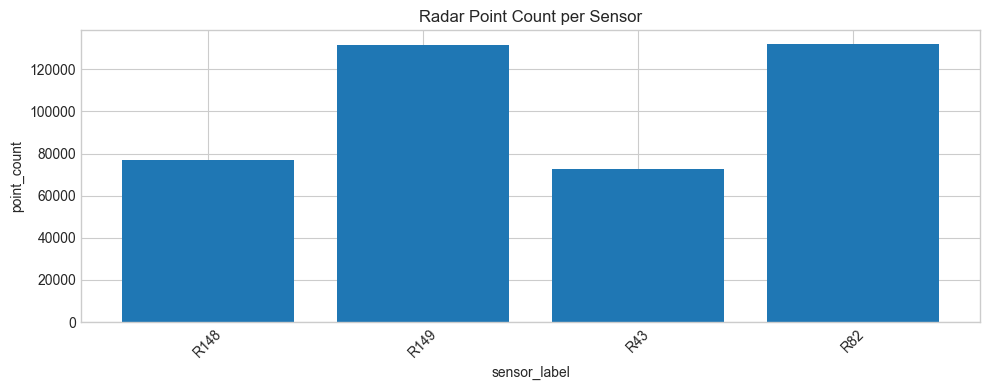

In [34]:
# Point count per radar sensor (table + bar chart)
# Uses sensor_label when available (new capture format), otherwise sensor_id.

count_key = "sensor_label" if "sensor_label" in radar_df.columns else "sensor_id"

radar_point_counts = (
    radar_df.groupby(count_key)
    .size()
    .rename("point_count")
    .reset_index()
    .sort_values(count_key)
)

total_points = int(radar_point_counts["point_count"].sum())
print(f"Grouping key: {count_key}")
print(f"Total radar points: {total_points:,}")

display(radar_point_counts)

plt.figure(figsize=(10, 4))
plt.bar(radar_point_counts[count_key].astype(str), radar_point_counts["point_count"])
plt.title("Radar Point Count per Sensor")
plt.xlabel(count_key)
plt.ylabel("point_count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Cars and the radar sensors they appear on.
# Uses sensor_label when present; falls back to sensor_id.
radar_key = "sensor_label" if "sensor_label" in radar_df.columns else "sensor_id"

radar_hits = radar_df.copy()
radar_hits = radar_hits[radar_hits["matched_vehicle_id"].notna()].copy()
radar_hits["vehicle_id"] = pd.to_numeric(radar_hits["matched_vehicle_id"], errors="coerce")
radar_hits = radar_hits[radar_hits["vehicle_id"].notna()].copy()
radar_hits["vehicle_id"] = radar_hits["vehicle_id"].astype(int)

car_to_radars = (
    radar_hits.groupby("vehicle_id")[radar_key]
    .agg(lambda s: sorted({str(v) for v in s if pd.notna(v) and str(v) != ""}))
    .reset_index(name="radars_seen_on")
)
car_to_radars["radars_seen_on"] = car_to_radars["radars_seen_on"].apply(lambda vals: ", ".join(vals))
car_to_radars["radar_count"] = car_to_radars["radars_seen_on"].apply(lambda x: 0 if x == "" else len(x.split(", ")))
car_to_radars = car_to_radars.sort_values(["radar_count", "vehicle_id"], ascending=[False, True]).reset_index(drop=True)

vehicle_radar_counts = (
    radar_hits.groupby(["vehicle_id", radar_key])
    .size()
    .reset_index(name="detection_count")
    .sort_values(["vehicle_id", "detection_count"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Unique labeled cars detected by radar: {car_to_radars['vehicle_id'].nunique()}")
display(car_to_radars)
print("\nPer-car, per-radar detection counts:")
display(vehicle_radar_counts)

Unique labeled cars detected by radar: 17


,vehicle_id,radars_seen_on,radar_count
0,29,"R148, R149, R43, R82",4
1,31,"R148, R149, R43, R82",4
2,32,"R148, R149, R43, R82",4
3,33,"R148, R149, R43, R82",4
4,34,"R148, R149, R43, R82",4
5,35,"R148, R149, R43, R82",4
6,36,"R148, R149, R43, R82",4
7,37,"R148, R149, R43, R82",4
8,38,"R148, R149, R43, R82",4
9,40,"R148, R149, R43, R82",4



Per-car, per-radar detection counts:


,vehicle_id,sensor_label,detection_count
0,29,R149,6467
1,29,R82,6219
2,29,R148,3516
3,29,R43,3307
4,31,R149,6236
...,...,...,...
60,47,R149,16045
61,47,R82,15407
62,47,R148,10884
63,47,R43,8919


In [36]:
# Point-type breakdown per radar sensor.
# With current CSV schema we can reliably identify:
# - car points: matched to a vehicle id
# - static/other: unmatched points
# For car points, split by radial speed magnitude.
SPEED_EPS_MPS = 0.5
sensor_key = "sensor_label" if "sensor_label" in radar_df.columns else "sensor_id"

radar_cls = radar_df.copy()
radar_cls["has_vehicle_match"] = radar_cls["matched_vehicle_id"].notna() & (
    radar_cls["matched_vehicle_id"].astype(str).str.strip() != ""
)
radar_cls["speed_abs_mps"] = radar_cls["velocity_mps"].abs()

radar_cls["point_type"] = np.where(
    ~radar_cls["has_vehicle_match"],
    "unmatched_static_or_other",
    np.where(radar_cls["speed_abs_mps"] > SPEED_EPS_MPS, "car_moving", "car_stationary"),
)

point_type_counts = (
    radar_cls.groupby([sensor_key, "point_type"]).size().reset_index(name="point_count")
)

point_type_summary = (
    point_type_counts.pivot(index=sensor_key, columns="point_type", values="point_count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

for col in ["car_moving", "car_stationary", "unmatched_static_or_other"]:
    if col not in point_type_summary.columns:
        point_type_summary[col] = 0

point_type_summary["total_points"] = (
    point_type_summary["car_moving"]
    + point_type_summary["car_stationary"]
    + point_type_summary["unmatched_static_or_other"]
)

point_type_summary["car_total"] = (
    point_type_summary["car_moving"] + point_type_summary["car_stationary"]
)
point_type_summary["car_pct"] = (
    100.0 * point_type_summary["car_total"] / point_type_summary["total_points"]
)
point_type_summary["unmatched_pct"] = (
    100.0 * point_type_summary["unmatched_static_or_other"] / point_type_summary["total_points"]
)

point_type_summary = point_type_summary.sort_values(sensor_key).reset_index(drop=True)

display(point_type_summary)
print("Legend: unmatched_static_or_other = no matched vehicle id in radar CSV.")
print(f"Moving/stationary split threshold: |velocity_mps| > {SPEED_EPS_MPS} m/s")

point_type,sensor_label,car_moving,car_stationary,unmatched_static_or_other,total_points,car_total,car_pct,unmatched_pct
0,R148,47826,29257,0,77083,77083,100.0,0.0
1,R149,78341,53037,0,131378,131378,100.0,0.0
2,R43,41822,30773,0,72595,72595,100.0,0.0
3,R82,77406,54443,0,131849,131849,100.0,0.0


Legend: unmatched_static_or_other = no matched vehicle id in radar CSV.
Moving/stationary split threshold: |velocity_mps| > 0.5 m/s


In [37]:
# Car vs truck radar point-cloud comparison.
# NOTE: radar_data.csv has matched_vehicle_id but not actor type, so we provide a mapping.
# Fill these from your scenario labels (or a separate vehicle metadata export).
vehicle_class_map = {
    # Example:
    # 101: "car",
    # 205: "truck",
}

if not vehicle_class_map:
    print("vehicle_class_map is empty. Add vehicle_id -> 'car'/'truck' entries to run this comparison.")
else:
    cls_df = radar_df.copy()
    cls_df = cls_df[cls_df["matched_vehicle_id"].notna()].copy()
    cls_df["vehicle_id"] = pd.to_numeric(cls_df["matched_vehicle_id"], errors="coerce")
    cls_df = cls_df[cls_df["vehicle_id"].notna()].copy()
    cls_df["vehicle_id"] = cls_df["vehicle_id"].astype(int)

    class_map_norm = {
        int(k): str(v).strip().lower()
        for k, v in vehicle_class_map.items()
        if str(v).strip().lower() in {"car", "truck"}
    }
    cls_df["vehicle_class"] = cls_df["vehicle_id"].map(class_map_norm)
    cls_df = cls_df[cls_df["vehicle_class"].isin(["car", "truck"])].copy()

    if cls_df.empty:
        print("No matched radar points for mapped car/truck ids. Check vehicle_class_map ids.")
    else:
        # Core numeric descriptors of radar points by class.
        class_stats = (
            cls_df.groupby("vehicle_class")[["depth_m", "azimuth_rad", "altitude_rad", "velocity_mps"]]
            .agg(["count", "mean", "std", "median", "min", "max"])
        )
        display(class_stats)

        # Per-sensor comparison (helps show where each class appears).
        sensor_key = "sensor_label" if "sensor_label" in cls_df.columns else "sensor_id"
        class_sensor_counts = (
            cls_df.groupby([sensor_key, "vehicle_class"]).size().reset_index(name="point_count")
        )
        class_sensor_pivot = (
            class_sensor_counts.pivot(index=sensor_key, columns="vehicle_class", values="point_count")
            .fillna(0)
            .astype(int)
            .reset_index()
        )
        for c in ["car", "truck"]:
            if c not in class_sensor_pivot.columns:
                class_sensor_pivot[c] = 0
        class_sensor_pivot["truck_to_car_ratio"] = np.where(
            class_sensor_pivot["car"] > 0,
            class_sensor_pivot["truck"] / class_sensor_pivot["car"],
            np.nan,
        )
        display(class_sensor_pivot.sort_values(sensor_key))

        # Distribution plots for quick visual comparison.
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        features = ["depth_m", "velocity_mps", "azimuth_rad", "altitude_rad"]
        for ax, feat in zip(axes.ravel(), features):
            ax.hist(
                cls_df.loc[cls_df["vehicle_class"] == "car", feat].dropna(),
                bins=60,
                alpha=0.6,
                label="car",
            )
            ax.hist(
                cls_df.loc[cls_df["vehicle_class"] == "truck", feat].dropna(),
                bins=60,
                alpha=0.6,
                label="truck",
            )
            ax.set_title(f"{feat}: car vs truck")
            ax.legend()     
        plt.tight_layout()
        plt.show()

        print(
            f"Compared {len(cls_df):,} matched radar points across "
            f"{cls_df['vehicle_id'].nunique()} mapped vehicles."
        )

vehicle_class_map is empty. Add vehicle_id -> 'car'/'truck' entries to run this comparison.


In [ ]:
## Busiest Frames Analysis

Find the frame with the most radar detections, then inspect it and the next 10 frames at 50-frame intervals.
Each frame shows:
- A bar chart of radar points per sensor
- How many unique vehicles were detected in that frame
- The corresponding camera image (if available)

In [ ]:
from matplotlib.image import imread

radar_points_per_frame = radar_df.groupby("frame").size().sort_values(ascending=False)
busiest_frame = int(radar_points_per_frame.index[0])

print(f"Busiest frame: {busiest_frame}  ({int(radar_points_per_frame.iloc[0])} radar detections)")
print("Top 5 frames by radar points:")
display(radar_points_per_frame.head().to_frame("radar_points"))

frames_to_inspect = [busiest_frame + i * 50 for i in range(11)]

# Build a stable sensor order and display labels like "R43 (25)".
if {"sensor_label", "sensor_id"}.issubset(radar_df.columns):
    sensor_catalog = (
        radar_df[["sensor_label", "sensor_id"]]
        .drop_duplicates()
        .sort_values(["sensor_id", "sensor_label"])
        .reset_index(drop=True)
    )
    sensor_keys = [f"{r.sensor_label} ({int(r.sensor_id)})" for r in sensor_catalog.itertuples(index=False)]
else:
    sensor_keys = sorted(radar_df["sensor_label"].dropna().astype(str).unique())

camera_image_lookup: dict[int, str] = {}
if "image_path" in camera_df.columns and "frame" in camera_df.columns:
    camera_rows = camera_df.dropna(subset=["frame", "image_path"]).drop_duplicates(subset="frame")
    for row in camera_rows.itertuples(index=False):
        camera_image_lookup[int(row.frame)] = str(row.image_path)

camera_frame_arr = np.array(sorted(camera_image_lookup.keys())) if camera_image_lookup else np.array([])

def find_nearest_camera_frame(target_frame: int, max_delta: int = 25) -> int | None:
    """Return the camera frame closest to *target_frame*, or None if none within *max_delta*."""
    if camera_frame_arr.size == 0:
        return None
    idx = int(np.searchsorted(camera_frame_arr, target_frame, side="left"))
    candidates: list[int] = []
    if idx < len(camera_frame_arr):
        candidates.append(int(camera_frame_arr[idx]))
    if idx > 0:
        candidates.append(int(camera_frame_arr[idx - 1]))
    best = min(candidates, key=lambda f: abs(f - target_frame))
    return best if abs(best - target_frame) <= max_delta else None

for frame_num in frames_to_inspect:
    frame_radar = radar_df[radar_df["frame"] == frame_num]
    has_radar = not frame_radar.empty

    nearest_cam = find_nearest_camera_frame(frame_num)

    if not has_radar and nearest_cam is None:
        print(f"\n--- Frame {frame_num}: no radar or camera data, skipping ---")
        continue

    if has_radar:
        if {"sensor_label", "sensor_id"}.issubset(frame_radar.columns):
            grouped = frame_radar.groupby(["sensor_label", "sensor_id"]).size()
            labels = [f"{lbl} ({int(sid)})" for lbl, sid in grouped.index]
            points_per_sensor = pd.Series(grouped.values, index=labels)
            points_per_sensor = points_per_sensor.reindex(sensor_keys, fill_value=0)
        else:
            points_per_sensor = frame_radar.groupby("sensor_label").size()
            points_per_sensor = points_per_sensor.reindex(sensor_keys, fill_value=0)

        total_pts = int(points_per_sensor.sum())

        vehicle_col = None
        for col_name in ("matched_vehicle_id", "nearest_vehicle_id"):
            if col_name in frame_radar.columns:
                vehicle_col = col_name
                break
        if vehicle_col is not None:
            unique_vehicles = frame_radar[vehicle_col].dropna().nunique()
        else:
            unique_vehicles = None

        fig, ax = plt.subplots(figsize=(10, 4))
        points_per_sensor.plot.bar(ax=ax, color="#1f77b4")
        ax.set_title(f"Per-Sensor Radar Point Distribution (Frame {frame_num})")
        ax.set_xlabel("Sensor (label and id)")
        ax.set_ylabel("Point count")
        ax.tick_params(axis="x", rotation=45)
        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment("right")
        plt.tight_layout()
        plt.show()

        if unique_vehicles is not None:
            print(f"Frame {frame_num}: {total_pts} radar points | {unique_vehicles} unique vehicle(s) detected")
        else:
            print(f"Frame {frame_num}: {total_pts} radar points")

    if nearest_cam is not None:
        img_path = Path(camera_image_lookup[nearest_cam])
        fig, ax = plt.subplots(figsize=(8, 5))
        if img_path.exists():
            ax.imshow(imread(str(img_path)))
            if nearest_cam == frame_num:
                ax.set_title(f"Camera Image (Frame {frame_num})")
            else:
                ax.set_title(f"Camera Image (Nearest Frame {nearest_cam}, delta={abs(nearest_cam - frame_num)})")
        else:
            ax.text(
                0.5,
                0.5,
                f"Image not found:\n{img_path.name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
            )
            ax.set_title(f"Camera Image (Frame {nearest_cam}) - Missing")
        ax.axis("off")
        plt.tight_layout()
        plt.show()